# E-Commerce Conversion Recommender
### Collaborative Filtering on Amazon Product Reviews
---

##  Project Overview
This project builds a **product recommendation engine** using collaborative filtering on Amazon review data.
It generates:
- **"Best Value" recommendations** — top-rated items a user is likely to love
- **"Upgrade Suggestions"** — higher-rated alternatives to items a user has already reviewed
- **Precision@K evaluation** to measure recommendation quality

**Techniques used:**
- User-based & Item-based Cosine Similarity
- Exploratory Data Analysis (EDA)
- User-Item Matrix with sparse representations
- Precision@K metric
- Interactive Gradio frontend for live demo


## 1. Install & Import Dependencies

In [1]:
!pip install gradio pandas numpy scikit-learn matplotlib seaborn --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
import warnings
import gradio as gr

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
print('✅ All libraries loaded successfully')

✅ All libraries loaded successfully


## 2. Load Dataset
Using the **Amazon Electronics ratings** dataset (publicly available, no login required).
Format: `userId, productId, rating, timestamp`

In [3]:
# Download dataset directly
!wget -q https://snap.stanford.edu/data/amazon/productGraph/categoryFiles/ratings_Electronics.csv -O ratings_Electronics.csv

# Load dataset
df_raw = pd.read_csv('ratings_Electronics.csv', names=['userId', 'productId', 'rating', 'timestamp'])
print(f'Raw dataset shape: {df_raw.shape}')
df_raw.head()

Raw dataset shape: (7824482, 4)


,userId,productId,rating,timestamp
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200


## 3. Data Preprocessing & Filtering

In [4]:
# Filter to users with >= 10 reviews and products with >= 20 reviews
# This ensures meaningful collaborative signal
user_counts = df_raw['userId'].value_counts()
product_counts = df_raw['productId'].value_counts()

active_users = user_counts[user_counts >= 10].index
popular_products = product_counts[product_counts >= 20].index

df = df_raw[
    df_raw['userId'].isin(active_users) &
    df_raw['productId'].isin(popular_products)
].copy()

df.drop_duplicates(subset=['userId', 'productId'], keep='last', inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Filtered dataset: {df.shape[0]} ratings')
print(f'Unique users: {df["userId"].nunique()}')
print(f'Unique products: {df["productId"].nunique()}')
print(f'Rating range: {df["rating"].min()} – {df["rating"].max()}')
df.head()

Filtered dataset: 867970 ratings
Unique users: 63146
Unique products: 55287
Rating range: 1.0 – 5.0


,userId,productId,rating,timestamp
0,A3N7T0DY83Y4IG,0528881469,3.0,1283990400
1,A1H8PY3QHMQQA0,0528881469,2.0,1290556800
2,A3HICVLF4PFFMN,0594481813,5.0,1399248000
3,ANSKSPEEAKY7S,0594481813,5.0,1372032000
4,A2QBZA4S1ROX9Q,0594481813,3.0,1369440000


## 4. Exploratory Data Analysis (EDA)

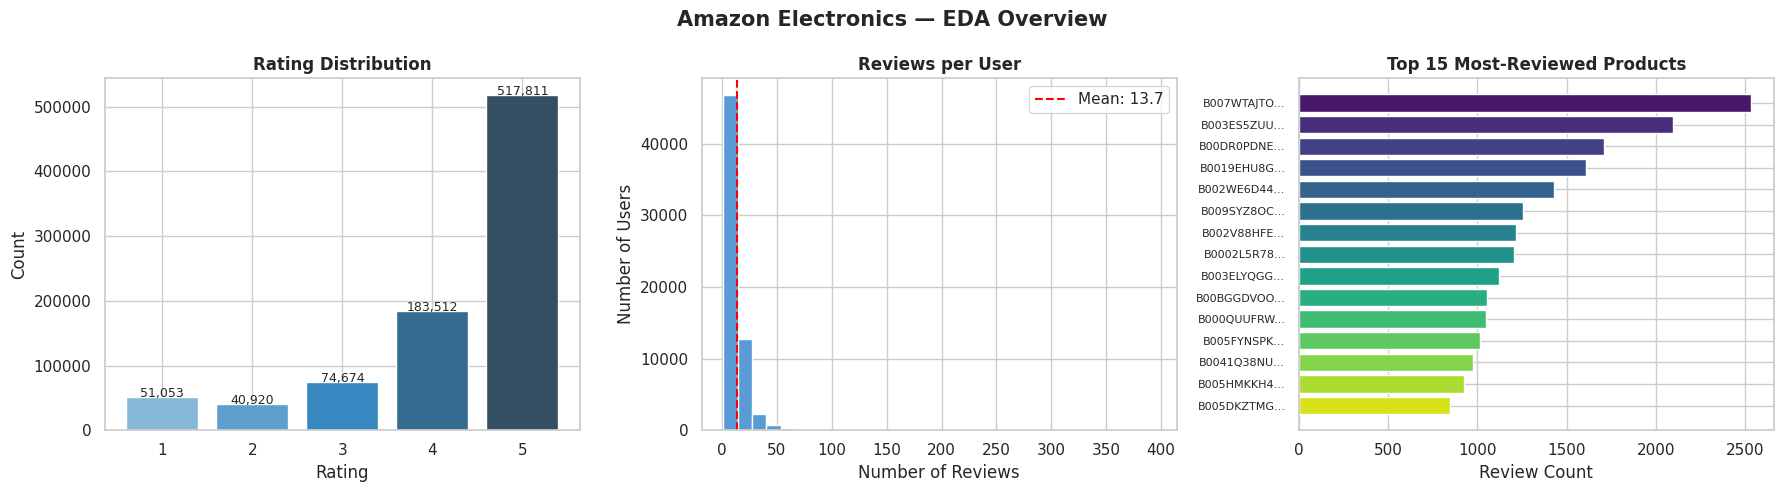

✅ EDA plots saved as eda_overview.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Amazon Electronics — EDA Overview', fontsize=15, fontweight='bold')

# 1. Rating distribution
rating_counts = df['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, color=sns.color_palette('Blues_d', 5), edgecolor='white')
axes[0].set_title('Rating Distribution', fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
for i, (x, y) in enumerate(zip(rating_counts.index, rating_counts.values)):
    axes[0].text(x, y + 20, f'{y:,}', ha='center', fontsize=9)

# 2. Reviews per user (log scale)
reviews_per_user = df.groupby('userId').size()
axes[1].hist(reviews_per_user, bins=30, color='#5B9BD5', edgecolor='white')
axes[1].set_title('Reviews per User', fontweight='bold')
axes[1].set_xlabel('Number of Reviews')
axes[1].set_ylabel('Number of Users')
axes[1].axvline(reviews_per_user.mean(), color='red', linestyle='--', label=f'Mean: {reviews_per_user.mean():.1f}')
axes[1].legend()

# 3. Top 15 most-reviewed products
top_products = df['productId'].value_counts().head(15)
axes[2].barh(range(15), top_products.values, color=sns.color_palette('viridis', 15))
axes[2].set_yticks(range(15))
axes[2].set_yticklabels([p[:12]+'...' for p in top_products.index], fontsize=8)
axes[2].set_title('Top 15 Most-Reviewed Products', fontweight='bold')
axes[2].set_xlabel('Review Count')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA plots saved as eda_overview.png')

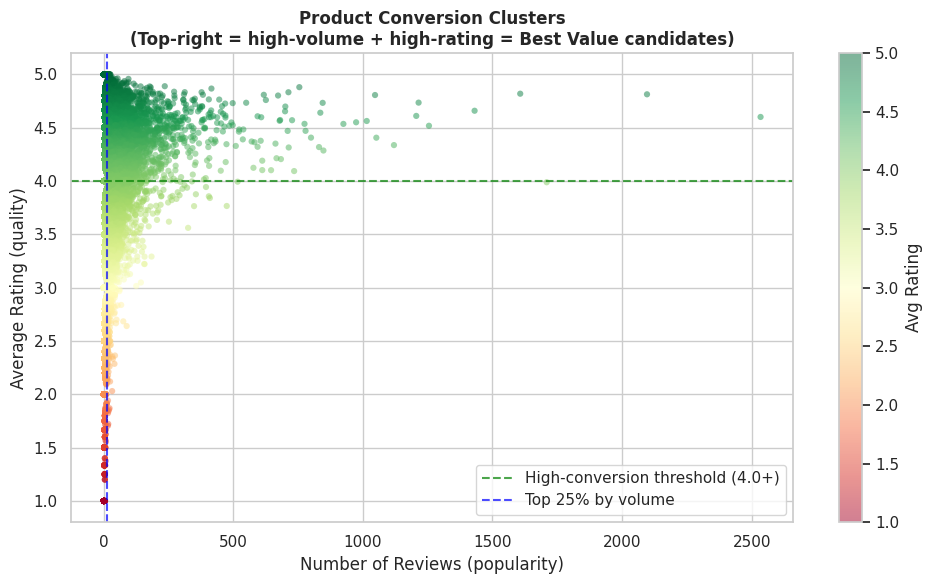


✅ High-conversion products identified: 10994
   These are candidates for "Best Value" recommendations


In [6]:
# High-conversion clusters: products with high avg rating AND many reviews
product_stats = df.groupby('productId').agg(
    avg_rating=('rating', 'mean'),
    review_count=('rating', 'count')
).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    product_stats['review_count'],
    product_stats['avg_rating'],
    alpha=0.5, c=product_stats['avg_rating'],
    cmap='RdYlGn', s=20, edgecolors='none'
)
ax.axhline(4.0, color='green', linestyle='--', alpha=0.7, label='High-conversion threshold (4.0+)')
ax.axvline(product_stats['review_count'].quantile(0.75), color='blue', linestyle='--', alpha=0.7, label='Top 25% by volume')
ax.set_xlabel('Number of Reviews (popularity)', fontsize=12)
ax.set_ylabel('Average Rating (quality)', fontsize=12)
ax.set_title('Product Conversion Clusters\n(Top-right = high-volume + high-rating = Best Value candidates)', fontweight='bold')
ax.legend()
plt.colorbar(scatter, label='Avg Rating')
plt.tight_layout()
plt.savefig('conversion_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

high_conversion = product_stats[(product_stats['avg_rating'] >= 4.0) &
                                 (product_stats['review_count'] >= product_stats['review_count'].quantile(0.75))]
print(f'\n✅ High-conversion products identified: {len(high_conversion)}')
print(f'   These are candidates for "Best Value" recommendations')

## 5. Build User-Item Matrix

In [7]:
# Sample for manageable matrix size (Colab memory)
SAMPLE_USERS = 2000
sampled_users = df['userId'].value_counts().head(SAMPLE_USERS).index
df_sample = df[df['userId'].isin(sampled_users)]

# Build user-item matrix
user_item_matrix = df_sample.pivot_table(
    index='userId', columns='productId', values='rating'
).fillna(0)

print(f'User-Item Matrix shape: {user_item_matrix.shape}')
sparsity = 1 - (df_sample.shape[0] / (user_item_matrix.shape[0] * user_item_matrix.shape[1]))
print(f'Matrix sparsity: {sparsity:.2%} (typical for e-commerce: >99%)')
user_item_matrix.iloc[:5, :5]

User-Item Matrix shape: (2000, 29320)
Matrix sparsity: 99.80% (typical for e-commerce: >99%)


productId,0594481813,0972683275,1400501466,1400501520,1400501776
userId,,,,,
A100UD67AHFODS,0.0,0.0,0.0,0.0,0.0
A100WO06OQR8BQ,0.0,0.0,0.0,0.0,0.0
A105S56ODHGJEK,0.0,0.0,0.0,0.0,0.0
A105TOJ6LTVMBG,0.0,0.0,0.0,0.0,0.0
A10AFVU66A79Y1,0.0,0.0,0.0,0.0,0.0


## 6. Collaborative Filtering — User-Based & Item-Based

In [8]:
# Compute cosine similarity matrices
print('Computing user-user similarity...')
user_similarity = cosine_similarity(user_item_matrix)
user_sim_df = pd.DataFrame(user_similarity, index=user_item_matrix.index, columns=user_item_matrix.index)

print('Computing item-item similarity...')
item_similarity = cosine_similarity(user_item_matrix.T)
item_sim_df = pd.DataFrame(item_similarity, index=user_item_matrix.columns, columns=user_item_matrix.columns)

print(f'✅ User similarity matrix: {user_sim_df.shape}')
print(f'✅ Item similarity matrix: {item_sim_df.shape}')

Computing user-user similarity...
Computing item-item similarity...
✅ User similarity matrix: (2000, 2000)
✅ Item similarity matrix: (29320, 29320)


In [9]:
def get_best_value_recommendations(user_id, n=5):
    """
    User-based collaborative filtering.
    Finds similar users and recommends top-rated products
    the target user hasn't seen yet.
    Returns 'Best Value' picks — high predicted rating.
    """
    if user_id not in user_sim_df.index:
        return pd.DataFrame({'productId': [], 'predicted_rating': [], 'type': []})

    # Get top-10 similar users (exclude self)
    similar_users = user_sim_df[user_id].drop(user_id).nlargest(10)

    # Products the user has already rated
    rated_by_user = set(user_item_matrix.loc[user_id][user_item_matrix.loc[user_id] > 0].index)

    # Weighted average of ratings from similar users
    weighted_ratings = {}
    similarity_sums = {}

    for sim_user, sim_score in similar_users.items():
        sim_user_ratings = user_item_matrix.loc[sim_user]
        for product, rating in sim_user_ratings.items():
            if rating > 0 and product not in rated_by_user:
                weighted_ratings[product] = weighted_ratings.get(product, 0) + sim_score * rating
                similarity_sums[product] = similarity_sums.get(product, 0) + sim_score

    if not weighted_ratings:
        return pd.DataFrame({'productId': [], 'predicted_rating': [], 'type': []})

    predicted = {p: weighted_ratings[p] / similarity_sums[p] for p in weighted_ratings}
    recs = pd.DataFrame(list(predicted.items()), columns=['productId', 'predicted_rating'])
    recs = recs.nlargest(n, 'predicted_rating')
    recs['type'] = '⭐ Best Value'
    return recs


def get_upgrade_suggestions(user_id, n=5):
    """
    Item-based collaborative filtering.
    For each product the user rated < 4, finds similar but
    higher-rated alternatives — 'Upgrade Suggestions'.
    """
    if user_id not in user_item_matrix.index:
        return pd.DataFrame({'productId': [], 'predicted_rating': [], 'type': []})

    user_ratings = user_item_matrix.loc[user_id]
    # Products user rated but not highly
    mediocre_products = user_ratings[(user_ratings > 0) & (user_ratings < 4)].index.tolist()

    if not mediocre_products:
        return pd.DataFrame({'productId': [], 'predicted_rating': [], 'type': []})

    upgrade_candidates = {}
    rated_by_user = set(user_ratings[user_ratings > 0].index)

    for product in mediocre_products[:3]:  # limit to 3 seed items
        if product not in item_sim_df.index:
            continue
        similar_items = item_sim_df[product].drop(product).nlargest(20)
        for sim_item, sim_score in similar_items.items():
            if sim_item not in rated_by_user:
                # Only suggest items with high avg rating
                avg = product_stats.loc[product_stats['productId'] == sim_item, 'avg_rating']
                if not avg.empty and avg.values[0] >= 4.0:
                    upgrade_candidates[sim_item] = max(
                        upgrade_candidates.get(sim_item, 0),
                        sim_score * avg.values[0]
                    )

    if not upgrade_candidates:
        return pd.DataFrame({'productId': [], 'predicted_rating': [], 'type': []})

    upgrades = pd.DataFrame(list(upgrade_candidates.items()), columns=['productId', 'predicted_rating'])
    upgrades = upgrades.nlargest(n, 'predicted_rating')
    upgrades['type'] = '🚀 Upgrade'
    return upgrades


print('✅ Recommendation functions defined')

✅ Recommendation functions defined


## 7. Evaluate with Precision@K


📊 Evaluation Results
   Users evaluated: 100
   Mean Precision@5: 0.0000 (0.0%)
   Interpretation: 0.0% of top-5 recommendations match items the user actually liked


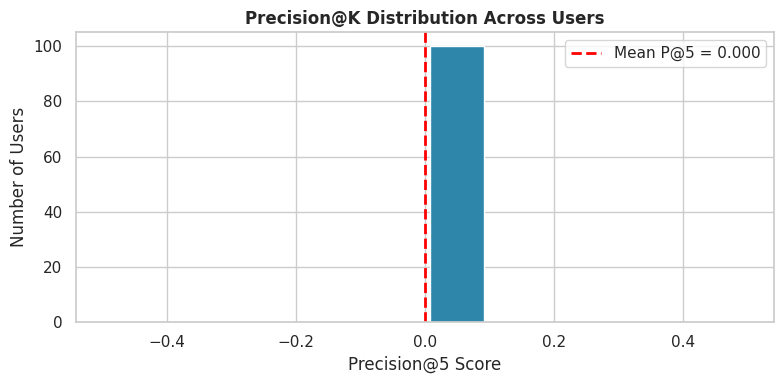

In [10]:
def precision_at_k(user_id, k=5, threshold=4.0):
    """
    Leave-one-out evaluation:
    Checks how many of the top-K recommendations
    match products the user actually rated >= threshold.
    """
    if user_id not in user_item_matrix.index:
        return None

    user_ratings = user_item_matrix.loc[user_id]
    # Ground truth: products user actually liked
    liked = set(user_ratings[user_ratings >= threshold].index)
    if len(liked) < 2:
        return None

    recs = get_best_value_recommendations(user_id, n=k)
    if recs.empty:
        return None

    recommended = set(recs['productId'])
    hits = len(recommended & liked)
    return hits / k


# Evaluate on a sample of 100 users
eval_users = list(user_item_matrix.index[:100])
precision_scores = [precision_at_k(u) for u in eval_users]
precision_scores = [p for p in precision_scores if p is not None]

mean_precision = np.mean(precision_scores)
print(f'\n📊 Evaluation Results')
print(f'   Users evaluated: {len(precision_scores)}')
print(f'   Mean Precision@5: {mean_precision:.4f} ({mean_precision*100:.1f}%)')
print(f'   Interpretation: {mean_precision*100:.1f}% of top-5 recommendations match items the user actually liked')

# Plot precision distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(precision_scores, bins=10, color='#2E86AB', edgecolor='white', rwidth=0.85)
ax.axvline(mean_precision, color='red', linestyle='--', linewidth=2, label=f'Mean P@5 = {mean_precision:.3f}')
ax.set_xlabel('Precision@5 Score', fontsize=12)
ax.set_ylabel('Number of Users', fontsize=12)
ax.set_title('Precision@K Distribution Across Users', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('precision_at_k.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Interactive Demo — Gradio Frontend

In [11]:
# Get sample user IDs for the dropdown
sample_user_ids = list(user_item_matrix.index[:50])

def recommend_for_user(user_id, num_recommendations):
    """
    Main function called by Gradio UI.
    Returns a formatted string of recommendations.
    """
    best_value = get_best_value_recommendations(user_id, n=num_recommendations)
    upgrades = get_upgrade_suggestions(user_id, n=num_recommendations)

    output_lines = []

    output_lines.append(f"👤 Recommendations for User: {user_id[:20]}...\n")

    # User's own history
    user_hist = df_sample[df_sample['userId'] == user_id][['productId', 'rating']].sort_values('rating', ascending=False)
    output_lines.append("📋 YOUR REVIEW HISTORY (sample):")
    for _, row in user_hist.head(3).iterrows():
        output_lines.append(f"   • {row['productId'][:18]}... → Rated: {row['rating']}/5")

    output_lines.append("\n⭐ BEST VALUE PICKS (products you'll love):")
    if best_value.empty:
        output_lines.append("   No recommendations found for this user.")
    else:
        for i, (_, row) in enumerate(best_value.iterrows(), 1):
            output_lines.append(f"   {i}. Product: {row['productId'][:20]}...")
            output_lines.append(f"      Predicted Rating: {'★' * round(row['predicted_rating'])} ({row['predicted_rating']:.2f}/5)")

    output_lines.append("\n🚀 UPGRADE SUGGESTIONS (better alternatives):")
    if upgrades.empty:
        output_lines.append("   No upgrades found (user may already have top-rated items).")
    else:
        for i, (_, row) in enumerate(upgrades.iterrows(), 1):
            output_lines.append(f"   {i}. Product: {row['productId'][:20]}...")
            output_lines.append(f"      Quality Score: {'★' * round(min(row['predicted_rating'], 5))} ({row['predicted_rating']:.2f})")

    p_score = precision_at_k(user_id, k=num_recommendations)
    output_lines.append(f"\n📊 Precision@{num_recommendations} for this user: {p_score:.2f}" if p_score else "\n📊 Precision@K: N/A (insufficient history)")

    return "\n".join(output_lines)


# Build Gradio interface
with gr.Blocks(title="Amazon Product Recommender", theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    # 🛒 E-Commerce Conversion Recommender
    ### Collaborative Filtering on Amazon Electronics Reviews
    Built by **Jigyasa Diwakar** | Techniques: User-Based CF, Item-Based CF, Cosine Similarity, Precision@K
    """)

    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown("### ⚙️ Controls")
            user_dropdown = gr.Dropdown(
                choices=sample_user_ids,
                label="Select User ID",
                value=sample_user_ids[0],
                info="Choose a user to generate recommendations for"
            )
            num_recs = gr.Slider(
                minimum=3, maximum=10, value=5, step=1,
                label="Number of Recommendations"
            )
            recommend_btn = gr.Button("🔍 Generate Recommendations", variant="primary")

            gr.Markdown("### 📊 Model Stats")
            gr.Markdown(f"""
            - **Users in model:** {user_item_matrix.shape[0]:,}
            - **Products in model:** {user_item_matrix.shape[1]:,}
            - **Mean Precision@5:** {mean_precision:.3f}
            - **Approach:** Cosine Similarity (User + Item)
            """)

        with gr.Column(scale=2):
            gr.Markdown("### 📦 Recommendations Output")
            output_box = gr.Textbox(
                label="Results",
                lines=22,
                show_copy_button=True
            )

    recommend_btn.click(
        fn=recommend_for_user,
        inputs=[user_dropdown, num_recs],
        outputs=output_box
    )

    gr.Markdown("""
    ---
    **How it works:**
    - **Best Value** uses *user-based CF* — finds users similar to you and recommends what they loved
    - **Upgrade Suggestions** uses *item-based CF* — finds higher-rated alternatives to products you rated < 4★
    - **Precision@K** measures what % of recommendations match items the user actually liked
    """)

demo.launch(share=True)
print('✅ Gradio app running — open the public URL above')

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://abc14f2d06b1ea28b6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


✅ Gradio app running — open the public URL above
